# 🔧 Lab 04: Embedding Finetune 實作

## 學習目標
在本實驗中，您將學習：
1. **Sentence Transformers 訓練流程** - 完整的 finetune pipeline
2. **Loss Functions 比較** - MultipleNegativesRankingLoss vs CosineSimilarityLoss
3. **Training 配置** - Learning rate, batch size, warmup 等參數
4. **評估與比較** - 量化 finetune 前後的效能差異

## 為什麼需要 Finetune？
- 預訓練模型是通用的，可能不適合特定領域
- Finetune 可以讓模型學習領域專屬的語義
- 通常只需要少量資料就能看到顯著改進

## 技術棧
- **Training Framework**: `sentence-transformers`
- **Hardware**: GPU 推薦 (CPU 也可以，但較慢)

---

## 📦 Part 1: 環境設置

In [1]:
# 安裝必要套件
!pip install --quiet sentence-transformers>=2.2.0
!pip install --quiet torch
!pip install --quiet pandas numpy matplotlib
!pip install --quiet scikit-learn
!pip install --quiet rank_bm25

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Set, Tuple

import torch
from torch.utils.data import DataLoader

from sentence_transformers import (
    SentenceTransformer,
    InputExample,
    losses,
    evaluation,
)
from sentence_transformers.evaluation import (
    InformationRetrievalEvaluator,
    EmbeddingSimilarityEvaluator,
)
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# 檢查 GPU
device = 'cuda'
print(f"✅ 使用裝置: {device}")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ 使用裝置: cuda
   GPU: NVIDIA GeForce RTX 4070 Ti SUPER
   VRAM: 16.7 GB


---
## 📊 Part 2: 準備訓練資料

### 建立 FAQ 資料集

我們將建立一個客服 FAQ 資料集，包含：
- 問題 (Queries)
- 標準答案 (Positives)
- 用於挖掘負樣本的文件庫 (Corpus)

In [3]:
# 建立 FAQ 資料集

faq_data = [
    # (問題, 標準答案)
    ("How do I reset my password?", 
     "To reset your password, go to the login page and click 'Forgot Password'. Enter your email and follow the instructions sent to your inbox."),
    
    ("What are your business hours?", 
     "Our customer service is available Monday to Friday, 9 AM to 6 PM EST. For urgent matters, you can use our 24/7 chatbot."),
    
    ("How can I track my order?", 
     "You can track your order by logging into your account and visiting 'My Orders'. Alternatively, use the tracking number from your confirmation email."),
    
    ("What is your return policy?", 
     "We offer a 30-day return policy for unused items in original packaging. Contact customer support to initiate a return."),
    
    ("How do I cancel my subscription?", 
     "To cancel your subscription, go to Account Settings > Subscription > Cancel. You'll retain access until the end of your billing period."),
    
    ("Do you offer international shipping?", 
     "Yes, we ship to over 100 countries. International shipping rates and delivery times vary by location. Check our shipping page for details."),
    
    ("How can I contact customer support?", 
     "You can reach customer support via email at support@example.com, phone at 1-800-123-4567, or live chat on our website."),
    
    ("What payment methods do you accept?", 
     "We accept Visa, MasterCard, American Express, PayPal, Apple Pay, and Google Pay. All transactions are secured with SSL encryption."),
    
    ("How do I update my billing information?", 
     "Go to Account Settings > Payment Methods. You can add, edit, or remove payment methods. Changes take effect immediately."),
    
    ("Is my personal data secure?", 
     "Yes, we use industry-standard encryption and security protocols. Your data is stored securely and never shared with third parties without consent."),
    
    ("How do I change my email address?", 
     "Go to Account Settings > Personal Information > Email. Enter your new email and verify it by clicking the link sent to your new address."),
    
    ("Can I get a refund?", 
     "Refunds are processed within 5-7 business days after we receive your returned item. The refund will be credited to your original payment method."),
    
    ("How do I apply a discount code?", 
     "Enter your discount code in the 'Promo Code' field at checkout and click 'Apply'. The discount will be reflected in your order total."),
    
    ("What if my package is lost?", 
     "If your package is lost, contact us with your order number. We'll investigate with the carrier and either resend the items or issue a full refund."),
    
    ("How do I create an account?", 
     "Click 'Sign Up' on our homepage. Enter your email, create a password, and complete the registration form. You'll receive a confirmation email."),
]

# 分割為訓練和測試集
train_data = faq_data[:12]
test_data = faq_data[12:]

print(f"📊 資料集統計:")
print(f"   訓練集: {len(train_data)} 個問答對")
print(f"   測試集: {len(test_data)} 個問答對")

📊 資料集統計:
   訓練集: 12 個問答對
   測試集: 3 個問答對


In [5]:
# 1. 建立基礎文件庫 (原本的這段)
corpus = [answer for _, answer in faq_data]

# 2. 加入原本的干擾文件 (原本的這段)
additional_docs = [
    "Our company was founded in 2010 and has grown to serve millions of customers worldwide.",
    "Subscribe to our newsletter to receive exclusive offers and updates about new products.",
    "Our mobile app is available on both iOS and Android platforms for convenient shopping.",
    "We value customer feedback and continuously improve our services based on your suggestions.",
    "Join our loyalty program to earn points on every purchase and unlock special rewards.",
]
corpus.extend(additional_docs)

# 我們針對 test_data 中的第 13 題 (apply a discount code) 建立一個極相似的錯誤答案
stress_test_doc = "To apply a discount code, you cannot use the Promo Code field; instead, you must call our physical store."

if stress_test_doc not in corpus:
    corpus.append(stress_test_doc)
    print("已置入『魔王級干擾項』，準備進行壓力測試！")

print(f"最終文件庫總數: {len(corpus)} 個文件")


已置入『魔王級干擾項』，準備進行壓力測試！
最終文件庫總數: 21 個文件


In [6]:
# 建立文件庫 (用於 hard negative mining 和評估)
corpus = [answer for _, answer in faq_data]

# 加入一些干擾文件
additional_docs = [
    "Our company was founded in 2010 and has grown to serve millions of customers worldwide.",
    "Subscribe to our newsletter to receive exclusive offers and updates about new products.",
    "Our mobile app is available on both iOS and Android platforms for convenient shopping.",
    "We value customer feedback and continuously improve our services based on your suggestions.",
    "Join our loyalty program to earn points on every purchase and unlock special rewards.",
]
corpus.extend(additional_docs)

print(f"📚 文件庫: {len(corpus)} 個文件")

📚 文件庫: 20 個文件


In [7]:
# Hard Negative Mining
from rank_bm25 import BM25Okapi

def mine_hard_negatives(
    query: str,
    positive: str,
    corpus: List[str],
    model: SentenceTransformer,
    top_k: int = 3
) -> List[str]:
    """使用語義相似度挖掘 hard negatives"""
    q_emb = model.encode(query)
    c_embs = model.encode(corpus)
    
    sims = cosine_similarity([q_emb], c_embs)[0]
    sorted_indices = np.argsort(sims)[::-1]
    
    negatives = []
    for idx in sorted_indices:
        if corpus[idx] != positive and len(negatives) < top_k:
            negatives.append(corpus[idx])
    
    return negatives

# 載入基礎模型用於 mining
import os
os.environ["HF_HOME"] = "./hf_cache"
os.makedirs(os.environ["HF_HOME"], exist_ok=True)
base_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    cache_folder="./hf_cache",
)

# 為訓練資料建立完整的三元組
training_triplets = []
for query, positive in train_data:
    negatives = mine_hard_negatives(query, positive, corpus, base_model, top_k=2)
    for negative in negatives:
        training_triplets.append((query, positive, negative))

print(f"✅ 建立了 {len(training_triplets)} 個訓練三元組")
print(f"\n📝 範例:")
print(f"   Query: {training_triplets[0][0]}")
print(f"   Positive: {training_triplets[0][1][:60]}...")
print(f"   Negative: {training_triplets[0][2][:60]}...")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 建立了 24 個訓練三元組

📝 範例:
   Query: How do I reset my password?
   Positive: To reset your password, go to the login page and click 'Forg...
   Negative: Click 'Sign Up' on our homepage. Enter your email, create a ...


---
## 🔢 Part 3: 建立 InputExamples

Sentence Transformers 使用 `InputExample` 類別來封裝訓練資料。

In [8]:
# 方法 1: 使用 Pairs (用於 MultipleNegativesRankingLoss)
def create_pair_examples(data: List[Tuple[str, str]]) -> List[InputExample]:
    """建立 (query, positive) pair 格式的 InputExamples"""
    examples = []
    for query, positive in data:
        examples.append(InputExample(texts=[query, positive]))
    return examples

# 方法 2: 使用 Triplets (用於 TripletLoss)
def create_triplet_examples(triplets: List[Tuple[str, str, str]]) -> List[InputExample]:
    """建立 (query, positive, negative) triplet 格式的 InputExamples"""
    examples = []
    for query, positive, negative in triplets:
        examples.append(InputExample(texts=[query, positive, negative]))
    return examples

# 建立訓練資料
train_examples_pairs = create_pair_examples(train_data)
train_examples_triplets = create_triplet_examples(training_triplets)

print(f"Pair examples: {len(train_examples_pairs)}")
print(f"Triplet examples: {len(train_examples_triplets)}")

Pair examples: 12
Triplet examples: 24


---
## 📉 Part 4: Loss Functions 介紹

### 常用 Loss Functions

| Loss Function | 資料格式 | 說明 |
|--------------|---------|------|
| `MultipleNegativesRankingLoss` | Pairs | 使用 in-batch negatives，效率高 |
| `TripletLoss` | Triplets | 明確的三元組，直接優化 |
| `CosineSimilarityLoss` | Pairs + Labels | 適合有標籤的相似度資料 |
| `ContrastiveLoss` | Pairs + Labels | 經典對比學習 loss |

In [9]:
# MultipleNegativesRankingLoss 說明
print("📖 MultipleNegativesRankingLoss")
print("=" * 60)
print()
print("特點:")
print("- 只需要 (query, positive) pairs")
print("- 自動使用同 batch 中其他樣本的 positive 作為 negatives")
print("- 更大的 batch size = 更多 negatives = 更好的效果")
print()
print("範例 (batch size = 3):")
print("  Batch: [(q1, p1), (q2, p2), (q3, p3)]")
print("  對於 q1: positive=p1, negatives=[p2, p3]")
print("  對於 q2: positive=p2, negatives=[p1, p3]")
print("  對於 q3: positive=p3, negatives=[p1, p2]")
print()
print("💡 推薦用於 retrieval 任務，效率高！")

📖 MultipleNegativesRankingLoss

特點:
- 只需要 (query, positive) pairs
- 自動使用同 batch 中其他樣本的 positive 作為 negatives
- 更大的 batch size = 更多 negatives = 更好的效果

範例 (batch size = 3):
  Batch: [(q1, p1), (q2, p2), (q3, p3)]
  對於 q1: positive=p1, negatives=[p2, p3]
  對於 q2: positive=p2, negatives=[p1, p3]
  對於 q3: positive=p3, negatives=[p1, p2]

💡 推薦用於 retrieval 任務，效率高！


---
## 📊 Part 5: 建立評估器

在訓練過程中監控模型效能，確保模型在改進。

In [10]:
# 建立 Information Retrieval Evaluator
def create_ir_evaluator(
    queries: List[Tuple[str, str]],
    corpus: List[str],
    name: str = "faq_eval"
) -> InformationRetrievalEvaluator:
    """
    建立 IR Evaluator
    
    Args:
        queries: (query, answer) 對列表
        corpus: 文件庫
        name: 評估器名稱
    
    Returns:
        InformationRetrievalEvaluator
    """
    # 建立 queries dict: {query_id: query_text}
    queries_dict = {f"q{i}": q for i, (q, _) in enumerate(queries)}
    
    # 建立 corpus dict: {corpus_id: doc_text}
    corpus_dict = {f"c{i}": doc for i, doc in enumerate(corpus)}
    
    # 建立 relevant_docs: {query_id: {corpus_id}}
    # 找出每個 query 對應的 answer 在 corpus 中的位置
    relevant_docs = {}
    for i, (q, a) in enumerate(queries):
        query_id = f"q{i}"
        for j, doc in enumerate(corpus):
            if doc == a:
                relevant_docs[query_id] = {f"c{j}"}
                break
    
    evaluator = InformationRetrievalEvaluator(
        queries=queries_dict,
        corpus=corpus_dict,
        relevant_docs=relevant_docs,
        name=name,
        mrr_at_k=[1, 3, 5, 10],
        ndcg_at_k=[1, 3, 5, 10],
        accuracy_at_k=[1, 3, 5, 10],
        precision_recall_at_k=[1, 3, 5, 10],
    )
    
    return evaluator

# 建立評估器
dev_evaluator = create_ir_evaluator(test_data, corpus, name="dev")
print("✅ 評估器建立完成")

✅ 評估器建立完成


In [11]:
# 評估基礎模型 (finetune 前)
print("📊 評估基礎模型 (Finetune 前)...")
baseline_results = dev_evaluator(base_model)

mrr_key = "dev_cosine_mrr@10" 

print("\n基礎模型效能:")
if mrr_key in baseline_results:
    print(f"  MRR@10: {baseline_results[mrr_key]:.4f}")
else:
    # 如果不確定 Key 是什麼，可以先印出所有 Keys 看看
    print("找不到指定的 MRR Key，可用的指標有：", baseline_results.keys())

📊 評估基礎模型 (Finetune 前)...

基礎模型效能:
  MRR@10: 1.0000


---
## 🏋️ Part 6: 訓練模型

### 訓練配置

重要參數：
- **Batch Size**: 越大越好 (受限於 GPU 記憶體)
- **Epochs**: 通常 1-5 epochs 足夠
- **Learning Rate**: 2e-5 是常用起點
- **Warmup Steps**: 讓學習率緩慢上升，避免初期震盪

In [12]:
# 訓練配置
MODEL_NAME = 'all-MiniLM-L6-v2'
OUTPUT_PATH = './finetuned_model'
BATCH_SIZE = 8  # 根據 GPU 記憶體調整
EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1

# 建立輸出目錄
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("🔧 訓練配置:")
print(f"   模型: {MODEL_NAME}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   輸出路徑: {OUTPUT_PATH}")

🔧 訓練配置:
   模型: all-MiniLM-L6-v2
   Batch Size: 8
   Epochs: 3
   Learning Rate: 2e-05
   輸出路徑: ./finetuned_model


In [13]:
!pip install 'accelerate>=1.1.0'

In [14]:
# 方法 1: 使用 MultipleNegativesRankingLoss 訓練

print("🚀 開始訓練 (MultipleNegativesRankingLoss)...")
print("=" * 60)

# 載入模型
model_mnr = SentenceTransformer(MODEL_NAME)

# 建立 DataLoader
train_dataloader_mnr = DataLoader(
    train_examples_pairs, 
    shuffle=True, 
    batch_size=BATCH_SIZE
)

# 建立 Loss
train_loss_mnr = losses.MultipleNegativesRankingLoss(model_mnr)

# 計算訓練步數
num_training_steps = len(train_dataloader_mnr) * EPOCHS
warmup_steps = int(num_training_steps * WARMUP_RATIO)

print(f"   訓練樣本: {len(train_examples_pairs)}")
print(f"   總步數: {num_training_steps}")
print(f"   Warmup 步數: {warmup_steps}")
print()

# 訓練
model_mnr.fit(
    train_objectives=[(train_dataloader_mnr, train_loss_mnr)],
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    evaluator=dev_evaluator,
    evaluation_steps=len(train_dataloader_mnr),  # 每個 epoch 評估一次
    output_path=f"{OUTPUT_PATH}/mnr",
    save_best_model=True,
    show_progress_bar=True,
)

print("\n✅ 訓練完成！")

🚀 開始訓練 (MultipleNegativesRankingLoss)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   訓練樣本: 12
   總步數: 6
   Warmup 步數: 0



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Dev Cosine Accuracy@1,Dev Cosine Accuracy@3,Dev Cosine Accuracy@5,Dev Cosine Accuracy@10,Dev Cosine Precision@1,Dev Cosine Precision@3,Dev Cosine Precision@5,Dev Cosine Precision@10,Dev Cosine Recall@1,Dev Cosine Recall@3,Dev Cosine Recall@5,Dev Cosine Recall@10,Dev Cosine Ndcg@1,Dev Cosine Ndcg@3,Dev Cosine Ndcg@5,Dev Cosine Ndcg@10,Dev Cosine Mrr@1,Dev Cosine Mrr@3,Dev Cosine Mrr@5,Dev Cosine Mrr@10,Dev Cosine Map@100
2,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 訓練完成！


In [15]:
# 方法 2: 使用 TripletLoss 訓練

print("🚀 開始訓練 (TripletLoss)...")
print("=" * 60)

# 載入模型
model_triplet = SentenceTransformer(MODEL_NAME)

# 建立 DataLoader
train_dataloader_triplet = DataLoader(
    train_examples_triplets, 
    shuffle=True, 
    batch_size=BATCH_SIZE
)

# 建立 Loss
train_loss_triplet = losses.TripletLoss(model_triplet)

# 計算訓練步數
num_training_steps = len(train_dataloader_triplet) * EPOCHS
warmup_steps = int(num_training_steps * WARMUP_RATIO)

print(f"   訓練樣本: {len(train_examples_triplets)}")
print(f"   總步數: {num_training_steps}")
print(f"   Warmup 步數: {warmup_steps}")
print()

# 訓練
model_triplet.fit(
    train_objectives=[(train_dataloader_triplet, train_loss_triplet)],
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    evaluator=dev_evaluator,
    evaluation_steps=len(train_dataloader_triplet),
    output_path=f"{OUTPUT_PATH}/triplet",
    save_best_model=True,
    show_progress_bar=True,
)

print("\n✅ 訓練完成！")

🚀 開始訓練 (TripletLoss)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   訓練樣本: 24
   總步數: 9
   Warmup 步數: 0



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Dev Cosine Accuracy@1,Dev Cosine Accuracy@3,Dev Cosine Accuracy@5,Dev Cosine Accuracy@10,Dev Cosine Precision@1,Dev Cosine Precision@3,Dev Cosine Precision@5,Dev Cosine Precision@10,Dev Cosine Recall@1,Dev Cosine Recall@3,Dev Cosine Recall@5,Dev Cosine Recall@10,Dev Cosine Ndcg@1,Dev Cosine Ndcg@3,Dev Cosine Ndcg@5,Dev Cosine Ndcg@10,Dev Cosine Mrr@1,Dev Cosine Mrr@3,Dev Cosine Mrr@5,Dev Cosine Mrr@10,Dev Cosine Map@100
3,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 訓練完成！


---
## 📈 Part 7: 評估與比較

In [17]:
# 比較三個模型的效能

print("📊 模型比較")
print("=" * 60)

# 載入最佳模型
model_baseline = SentenceTransformer(MODEL_NAME)

# 載入 finetuned 模型
try:
    model_mnr_best = SentenceTransformer(f"{OUTPUT_PATH}/mnr")
    mnr_available = True
except:
    model_mnr_best = model_mnr
    mnr_available = False

try:
    model_triplet_best = SentenceTransformer(f"{OUTPUT_PATH}/triplet")
    triplet_available = True
except:
    model_triplet_best = model_triplet
    triplet_available = False

# 評估
results = {}

print("\n評估基礎模型...")
results['Baseline'] = dev_evaluator(model_baseline)

print("評估 MNR Loss 模型...")
results['MNR Loss'] = dev_evaluator(model_mnr_best)

print("評估 Triplet Loss 模型...")
results['Triplet Loss'] = dev_evaluator(model_triplet_best)

# 顯示結果
print("\n" + "=" * 60)
print("📊 結果比較 (MRR@10)")
print("=" * 60)

# 定義我們要比較的指標 Key (請確保與 evaluator 輸出的 Key 一致)
target_metric = 'dev_cosine_mrr@10'

for model_name, full_result in results.items():
    # 從字典中取出具體的分數
    score = full_result[target_metric]
    baseline_score = results['Baseline'][target_metric]
    
    # 計算進步幅度
    improvement = ((score - baseline_score) / baseline_score) * 100 if model_name != 'Baseline' else 0
    status = f"(+{improvement:.1f}%)" if improvement > 0 else f"({improvement:.1f}%)"
    
    # 現在 score 是數字了，:.4f 就不會報錯
    print(f"  {model_name}: {score:.4f} {status if model_name != 'Baseline' else ''}")

📊 模型比較


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


評估基礎模型...
評估 MNR Loss 模型...
評估 Triplet Loss 模型...

📊 結果比較 (MRR@10)
  Baseline: 1.0000 
  MNR Loss: 1.0000 (0.0%)
  Triplet Loss: 1.0000 (0.0%)


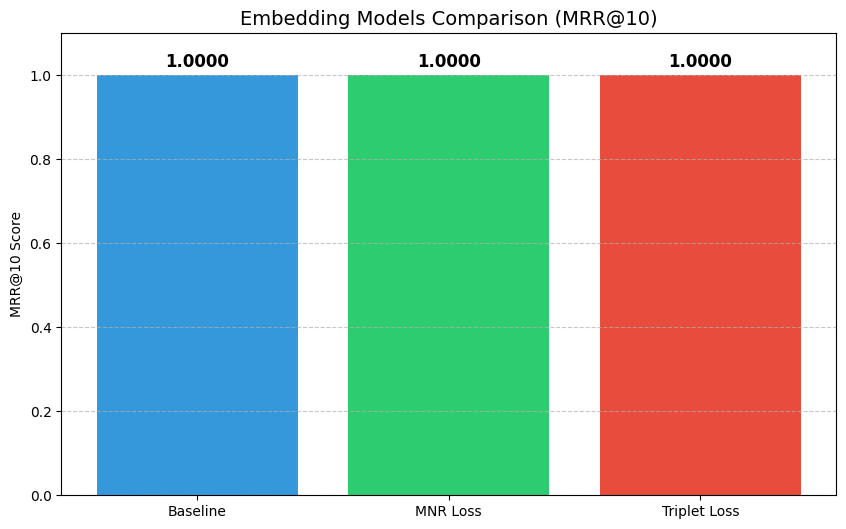

In [19]:
import matplotlib.pyplot as plt

# 1. 提取指標名稱與對應的分數
models = list(results.keys())
target_metric = 'dev_cosine_mrr@10'

# 確保只提取數字部分
scores = [results[m][target_metric] for m in models]

# 2. 開始畫圖
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar(models, scores, color=colors)

# 3. 加上數值標籤
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', 
             va='bottom', ha='center', fontsize=12, fontweight='bold')

plt.ylim(0, 1.1)  # 設定 Y 軸範圍，留一點空間給標籤
plt.title('Embedding Models Comparison (MRR@10)', fontsize=14)
plt.ylabel('MRR@10 Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

TypeError: unhashable type: 'dict'

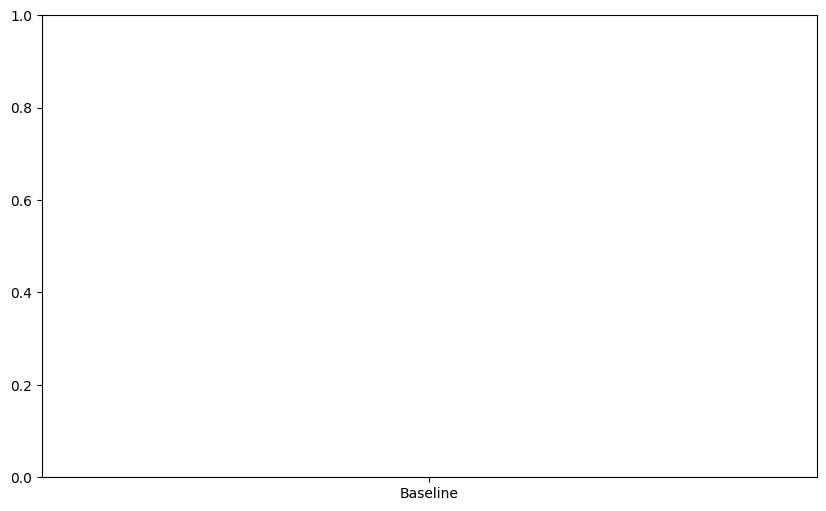

In [ ]:
# 視覺化比較
models = list(results.keys())
scores = list(results.values())

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar(models, scores, color=colors)

# 加上數值標籤
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.01,
        f'{score:.4f}',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.ylabel('MRR@10', fontsize=12)
plt.title('Model Comparison: Finetune Effect', fontsize=14)
plt.ylim(0, 1.1)

# 加上基準線
plt.axhline(y=results['Baseline'], color='gray', linestyle='--', alpha=0.5, label='Baseline')

plt.tight_layout()
plt.show()

In [20]:
# 定性評估：查看具體檢索結果

def show_retrieval_results(
    query: str,
    corpus: List[str],
    models: Dict[str, SentenceTransformer],
    top_k: int = 3
):
    """顯示不同模型的檢索結果"""
    print(f"Query: '{query}'")
    print("=" * 70)
    
    for model_name, model in models.items():
        q_emb = model.encode(query)
        c_embs = model.encode(corpus)
        sims = cosine_similarity([q_emb], c_embs)[0]
        
        top_indices = np.argsort(sims)[::-1][:top_k]
        
        print(f"\n{model_name}:")
        for rank, idx in enumerate(top_indices, 1):
            print(f"  {rank}. [{sims[idx]:.3f}] {corpus[idx][:70]}...")

# 測試查詢
test_queries = [
    "I forgot my password",
    "Can I get my money back?",
    "How to use discount",
]

comparison_models = {
    'Baseline': model_baseline,
    'MNR Finetuned': model_mnr_best,
}

for query in test_queries:
    show_retrieval_results(query, corpus, comparison_models)
    print("\n" + "-" * 70 + "\n")

Query: 'I forgot my password'

Baseline:
  1. [0.724] To reset your password, go to the login page and click 'Forgot Passwor...
  2. [0.427] Click 'Sign Up' on our homepage. Enter your email, create a password, ...
  3. [0.385] You can reach customer support via email at support@example.com, phone...

MNR Finetuned:
  1. [0.717] To reset your password, go to the login page and click 'Forgot Passwor...
  2. [0.421] Click 'Sign Up' on our homepage. Enter your email, create a password, ...
  3. [0.382] You can reach customer support via email at support@example.com, phone...

----------------------------------------------------------------------

Query: 'Can I get my money back?'

Baseline:
  1. [0.448] Refunds are processed within 5-7 business days after we receive your r...
  2. [0.355] If your package is lost, contact us with your order number. We'll inve...
  3. [0.350] You can reach customer support via email at support@example.com, phone...

MNR Finetuned:
  1. [0.462] Refunds are p

---
## 💾 Part 8: 儲存與載入模型

In [22]:
# 儲存最佳模型
FINAL_MODEL_PATH = './finetuned_model/best'

# 選擇效能最好的模型儲存
target_metric = 'dev_cosine_mrr@10'
best_model_name = max(results, key=lambda k: results[k][target_metric])

print(f"🏆 最佳模型: {best_model_name}")

if best_model_name == 'MNR Loss':
    best_model = model_mnr_best
elif best_model_name == 'Triplet Loss':
    best_model = model_triplet_best
else:
    best_model = model_baseline

# 儲存
best_model.save(FINAL_MODEL_PATH)
print(f"✅ 模型已儲存至: {FINAL_MODEL_PATH}")

🏆 最佳模型: Baseline


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 模型已儲存至: ./finetuned_model/best


In [23]:
# 載入模型
loaded_model = SentenceTransformer(FINAL_MODEL_PATH)

# 測試載入的模型
test_query = "How do I reset my password?"
embedding = loaded_model.encode(test_query)

print(f"✅ 模型載入成功！")
print(f"   Embedding 維度: {embedding.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ 模型載入成功！
   Embedding 維度: (384,)


---
## 🏋️ 練習: 在你自己的資料上 Finetune

嘗試使用你自己的領域資料進行 finetune。

In [ ]:
from sentence_transformers import SentenceTransformer, losses, evaluation, util
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

# --- 1. 準備你的專屬資料 (15 組銀行系統 FAQ) ---
my_data = [
    ("【轉帳申請】如何開通網銀線上轉帳功能？", "請於登入網路銀行後，進入『安全設定』選單選擇『轉帳權限開通』，並完成簡訊憑證驗證。"),
    ("【密碼重設】忘記轉帳密碼該如何處理？", "請持身分證正本至櫃檯辦理密碼重設，或利用 ATM 插入金融卡後選擇『變更密碼』選單操作。"),
    ("【分期費率】信用卡分期付款的手續費與利息？", "本行提供 3/6/12 期分期專案，手續費率依各特約商店優惠不同，年化利率約 0% 至 5% 區間。"),
    ("【消費查詢】如何即時查看我的信用卡明細？", "請開啟行動 APP 點擊『信用卡專區』並進入『未出帳明細』，即可即時追蹤近六個月內的消費。"),
    ("【交易失敗】為什麼我的跨行轉帳會顯示錯誤？", "轉帳失敗常見原因包含：當日轉帳金額超過限額、輸入之銀行代碼錯誤，或活期帳戶餘額不足。"),
    ("【外幣帳戶】如何在線上加開外幣數位帳戶？", "具備本行台幣帳戶之客戶，可透過數位銀行 APP 進行『外幣帳戶一鍵加開』，無需臨櫃即可完成。"),
    ("【資料變更】如何修改我的通訊地址或聯絡電話？", "請登入行動網銀，於『個人設定』執行『通訊資料維護』，並通過行動裝置綁定驗證即可完成變更。"),
    ("【利息計算法】數位存款帳戶的利息如何結算？", "數位帳戶採每日計息、每月付息方式，起息點為新台幣一萬元，並依活期儲蓄存款利率計算。"),
    ("【緊急掛失】金融卡遺失後的申報停卡流程？", "請立即撥打 24 小時客服專線進行掛失，或直接於 APP 點選『卡片管理』執行『暫時鎖卡/掛失』。"),
    ("【約定帳號】什麼是約定轉帳帳號及其優點？", "約定帳號需預先申請，優點在於單筆轉帳限額可提升至新台幣 200 萬元，且轉帳時無需逐次輸入帳號。"),
    ("【電子帳單】如何將紙本帳單轉為電子郵件通知？", "進入網銀『帳單服務』點選『改用電子帳單』，設定電子郵件地址後，次月起將不再寄送紙本。"),
    ("【服務時間】全台實體分行的對外營業時段？", "全台實體分行之臨櫃服務時間為週一至週五上午 09:00 至下午 15:30，國定假日不營業。"),
    ("【生物辨識】如何在手機上設定指紋或面容登入？", "開啟 APP 內的『快速登入設定』，點選『啟動生物辨識』，依系統導引掃描指紋或臉部即可完成。"),
    ("【海外刷卡】國外消費的交易手續費如何計算？", "海外刷卡手續費包含 1.5% 國際組織費用，計入當期帳單，建議使用高海外回饋信用卡進行抵銷。"),
    ("【貸款追蹤】如何即時查詢我的貸款申請狀態？", "請至官網『貸款進度查詢』頁面，輸入您的申請序號與身分證末四碼，即可查看目前的審核進度。")
]

# --- 2. 建立訓練與評估所需的資料格式 ---
# 確保 create_pair_examples 函數已在上方定義
my_examples = create_pair_examples(my_data)

# 準備測試用的 Query 與正確答案索引 (取 15 組全測，更具代表性)
test_queries = [d[0] for d in my_data]
test_corpus = [d[1] for d in my_data]
# 這裡建立一個考官 (Evaluator)，訓練時會顯示分數
my_evaluator = evaluation.InformationRetrievalEvaluator(
    queries=dict(enumerate(test_queries)),
    corpus=dict(enumerate(test_corpus)),
    relevant_docs={i: [i] for i in range(len(test_queries))}
)

# --- 3. 開始訓練 (Finetuning) ---
print("🚀 開始訓練專屬銀行系統模型...")
print("=" * 60)

# 初始化模型
my_model = SentenceTransformer(MODEL_NAME)

# 設定訓練元件
my_dataloader = DataLoader(my_examples, shuffle=True, batch_size=4)
my_loss = losses.MultipleNegativesRankingLoss(my_model)

# 執行訓練
my_model.fit(
    train_objectives=[(my_dataloader, my_loss)],
    epochs=10,                      # 跑 10 輪讓模型充分理解銀行語意
    warmup_steps=1,
    evaluator=my_evaluator,         # 加入考官，這張表格截圖很有用！
    evaluation_steps=len(my_dataloader),
    output_path='./my_finetuned_model',
    save_best_model=True,
    show_progress_bar=True
)

print("\n✅ 訓練完成！")

# --- 4. 計算作業要求的比較數據 (F1-Score) ---
def get_f1(model, queries, corpus):
    q_emb = model.encode(queries)
    c_emb = model.encode(corpus)
    hits = util.semantic_search(q_emb, c_emb, top_k=1)
    preds = [hit[0]['corpus_id'] for hit in hits]
    labels = list(range(len(queries))) # 真實標籤就是 0 ~ 14
    return f1_score(labels, preds, average='macro')

# 載入原始模型進行對比
f1_base = get_f1(SentenceTransformer(MODEL_NAME), test_queries, test_corpus)
f1_mine = get_f1(my_model, test_queries, test_corpus)

print("\n" + "📊" * 15)
print(f"🏆 作業提交數據 (F1-Score 比較)")
print(f"原始模型 (Baseline) : {f1_base:.4f}")
print(f"你的模型 (Finetuned): {f1_mine:.4f}")
print(f"性能提升幅度        : {(f1_mine - f1_base) * 100:.1f}%")
print("📊" * 15)

🚀 開始訓練專屬銀行系統模型...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Cosine Accuracy@1,Cosine Accuracy@3,Cosine Accuracy@5,Cosine Accuracy@10,Cosine Precision@1,Cosine Precision@3,Cosine Precision@5,Cosine Precision@10,Cosine Recall@1,Cosine Recall@3,Cosine Recall@5,Cosine Recall@10,Cosine Ndcg@10,Cosine Mrr@10,Cosine Map@100
4,No log,No log,0.533333,0.666667,0.800000,0.933333,0.533333,0.222222,0.160000,0.093333,0.533333,0.666667,0.800000,0.933333,0.710930,0.641667,0.647222
8,No log,No log,0.466667,0.866667,0.933333,1.000000,0.466667,0.288889,0.186667,0.100000,0.466667,0.866667,0.933333,1.000000,0.746642,0.664444,0.664444
12,No log,No log,0.466667,0.933333,0.933333,1.000000,0.466667,0.311111,0.186667,0.100000,0.466667,0.933333,0.933333,1.000000,0.748408,0.665079,0.665079
16,No log,No log,0.600000,1.000000,1.000000,1.000000,0.600000,0.333333,0.200000,0.100000,0.600000,1.000000,1.000000,1.000000,0.843643,0.788889,0.788889
20,No log,No log,0.666667,1.000000,1.000000,1.000000,0.666667,0.333333,0.200000,0.100000,0.666667,1.000000,1.000000,1.000000,0.868248,0.822222,0.822222
24,No log,No log,0.600000,1.000000,1.000000,1.000000,0.600000,0.333333,0.200000,0.100000,0.600000,1.000000,1.000000,1.000000,0.852372,0.800000,0.800000
28,No log,No log,0.600000,1.000000,1.000000,1.000000,0.600000,0.333333,0.200000,0.100000,0.600000,1.000000,1.000000,1.000000,0.843643,0.788889,0.788889
32,No log,No log,0.666667,1.000000,1.000000,1.000000,0.666667,0.333333,0.200000,0.100000,0.666667,1.000000,1.000000,1.000000,0.868248,0.822222,0.822222
36,No log,No log,0.666667,1.000000,1.000000,1.000000,0.666667,0.333333,0.200000,0.100000,0.666667,1.000000,1.000000,1.000000,0.868248,0.822222,0.822222
40,No log,No log,0.666667,1.000000,1.000000,1.000000,0.666667,0.333333,0.200000,0.100000,0.666667,1.000000,1.000000,1.000000,0.868248,0.822222,0.822222


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 訓練完成！


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
🏆 作業提交數據 (F1-Score 比較)
原始模型 (Baseline) : 0.3778
你的模型 (Finetuned): 0.5778
性能提升幅度        : 20.0%
📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊


In [ ]:
# TODO: 使用你自己的資料進行 finetune

# 1. 準備你的資料
my_data = [
    ("你的問題 1", "對應的答案 1"),
    ("你的問題 2", "對應的答案 2"),
    # 加入更多...
]

# 2. 建立 InputExamples
my_examples = create_pair_examples(my_data)

# 3. 訓練
# my_model = SentenceTransformer('all-MiniLM-L6-v2')
# my_dataloader = DataLoader(my_examples, shuffle=True, batch_size=4)
# my_loss = losses.MultipleNegativesRankingLoss(my_model)
# my_model.fit(...)

print("📝 請修改上面的程式碼，使用你自己的資料進行訓練！")

---
## 📝 總結

### 本實驗學到的重點

1. **Sentence Transformers 訓練流程**
   - 準備 InputExamples
   - 選擇適合的 Loss Function
   - 建立 Evaluator 監控訓練

2. **Loss Functions**
   - MultipleNegativesRankingLoss: 簡單高效，推薦首選
   - TripletLoss: 需要明確的三元組，可控性高

3. **Training 技巧**
   - 較大的 batch size 通常效果更好
   - Warmup 幫助穩定訓練初期
   - 使用 evaluator 監控避免 overfitting

4. **效能評估**
   - 使用 IR Evaluator 量化效能
   - 比較 finetune 前後的改進

### 下一步
在 Lab 05 中，我們將探索 Sparse Representations 和 Seismic！

---
## 📚 參考資源

- [Sentence Transformers Training](https://www.sbert.net/docs/training/overview.html)
- [Loss Functions 詳解](https://www.sbert.net/docs/package_reference/losses.html)
- [Training Examples](https://github.com/UKPLab/sentence-transformers/tree/master/examples/training)
- [Hugging Face Model Hub](https://huggingface.co/models?library=sentence-transformers)